# **Sales & Demand Forecasting for Businesses**

In [107]:
import pandas as pd
pd.set_option('display.max_columns', None)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score, KFold

#metraics
from sklearn.metrics import mean_squared_error, r2_score

In [64]:
data  = pd.read_csv(r"Data\Sample - Superstore.csv", encoding='latin-1')
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [65]:
print(f"Data shape: {data.shape}")

Data shape: (9994, 21)


### **Feature Engingeering**

#### 1. Month and Year columns

In [66]:
data['Order Date'] = pd.to_datetime(data['Order Date'], format='%m/%d/%Y')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], format='%m/%d/%Y')

data['month'] = data['Order Date'].dt.month
data['year'] = data['Order Date'].dt.year

#### 2. Shipping Time

In [67]:
data['Shipping_Time'] = (data['Ship Date'] - data['Order Date']).dt.days

In [68]:
columns = ['Row ID', 'Order ID',
       'month', 'year', 'Shipping_Time', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Quantity', 'Discount', 'Profit',  'Sales']

data = data[columns]
data.head()

,Row ID,Order ID,month,year,Shipping_Time,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Quantity,Discount,Profit,Sales
0,1,CA-2016-152156,11,2016,3,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,2,0.00,41.9136,261.9600
1,2,CA-2016-152156,11,2016,3,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",3,0.00,219.5820,731.9400
2,3,CA-2016-138688,6,2016,4,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,2,0.00,6.8714,14.6200
3,4,US-2015-108966,10,2015,7,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,5,0.45,-383.0310,957.5775
4,5,US-2015-108966,10,2015,7,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,2,0.20,2.5164,22.3680


#### Data Preprocess

In [69]:
# Checking for missing values
data.isnull().sum()

Row ID           0
Order ID         0
month            0
year             0
Shipping_Time    0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Discount         0
Profit           0
Sales            0
dtype: int64

In [70]:
# Cheching for duplicates
data.duplicated().sum()

np.int64(0)

## **Visualization**

### Sales vs Profit of Region

In [71]:
data['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

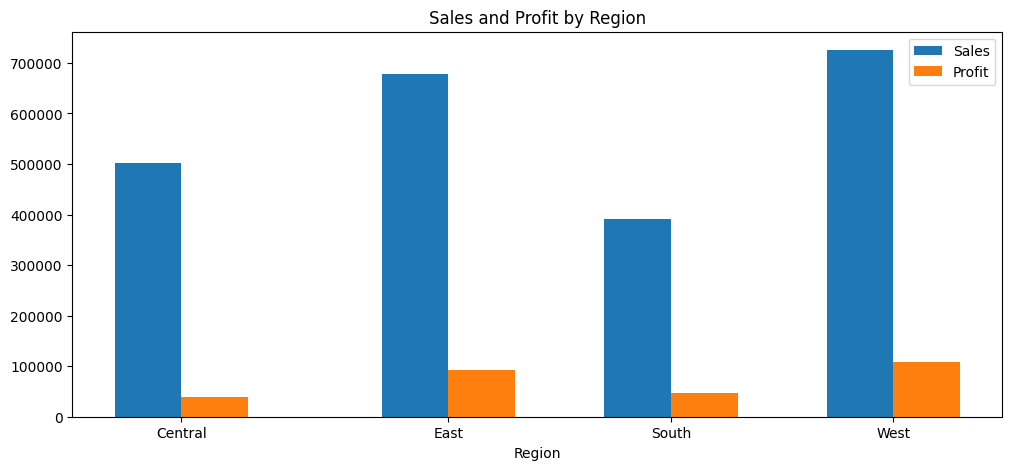

In [72]:
# Plot sales and profit by region 
region_sale = data.groupby('Region')['Sales'].sum().reset_index()
region_profit = data.groupby('Region')['Profit'].sum().reset_index()


plt.figure(figsize=(12, 5))
plt.bar(x=[0.3, 1.5, 2.5, 3.5], height=region_sale['Sales'], label='Sales', width=0.3)
plt.bar(x=[0.6, 1.8, 2.8, 3.8], height=region_profit['Profit'], label='Profit', width=0.3)

plt.xticks(ticks=[0.45, 1.65, 2.65, 3.65], labels=region_sale['Region'])
plt.xlabel('Region')
plt.title('Sales and Profit by Region')
plt.legend()
plt.show()

### Visualizing sales and profit by Segment

In [73]:
data['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

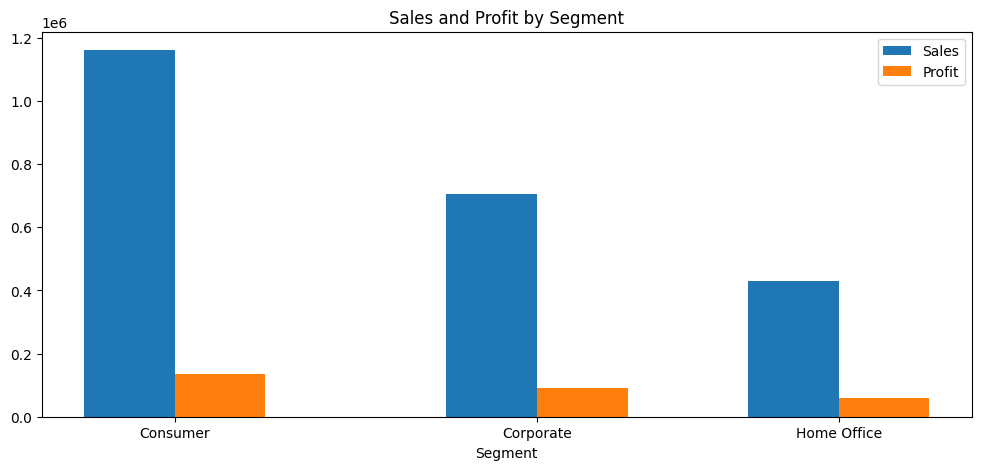

In [74]:
segment_sale = data.groupby('Segment')['Sales'].sum().reset_index()
segment_profit = data.groupby('Segment')['Profit'].sum().reset_index()

plt.figure(figsize=(12, 5))

plt.bar(x=[0.3, 1.5, 2.5], height=segment_sale['Sales'], label='Sales', width=0.3)
plt.bar(x=[0.6, 1.8, 2.8], height=segment_profit['Profit'], label='Profit', width=0.3)

plt.xticks(ticks=[0.45, 1.65, 2.65], labels=data['Segment'].unique())
plt.xlabel('Segment')
plt.title('Sales and Profit by Segment')
plt.legend()
plt.show()

### Monthly And Yearly Sales, Profits

In [75]:
data['year'].unique()

array([2016, 2015, 2014, 2017], dtype=int32)

In [76]:
yearly_group = data.groupby('year')


year_2017 = yearly_group.get_group(2017)
year_2016 = yearly_group.get_group(2016)
year_2015 = yearly_group.get_group(2015)
year_2014 = yearly_group.get_group(2014)

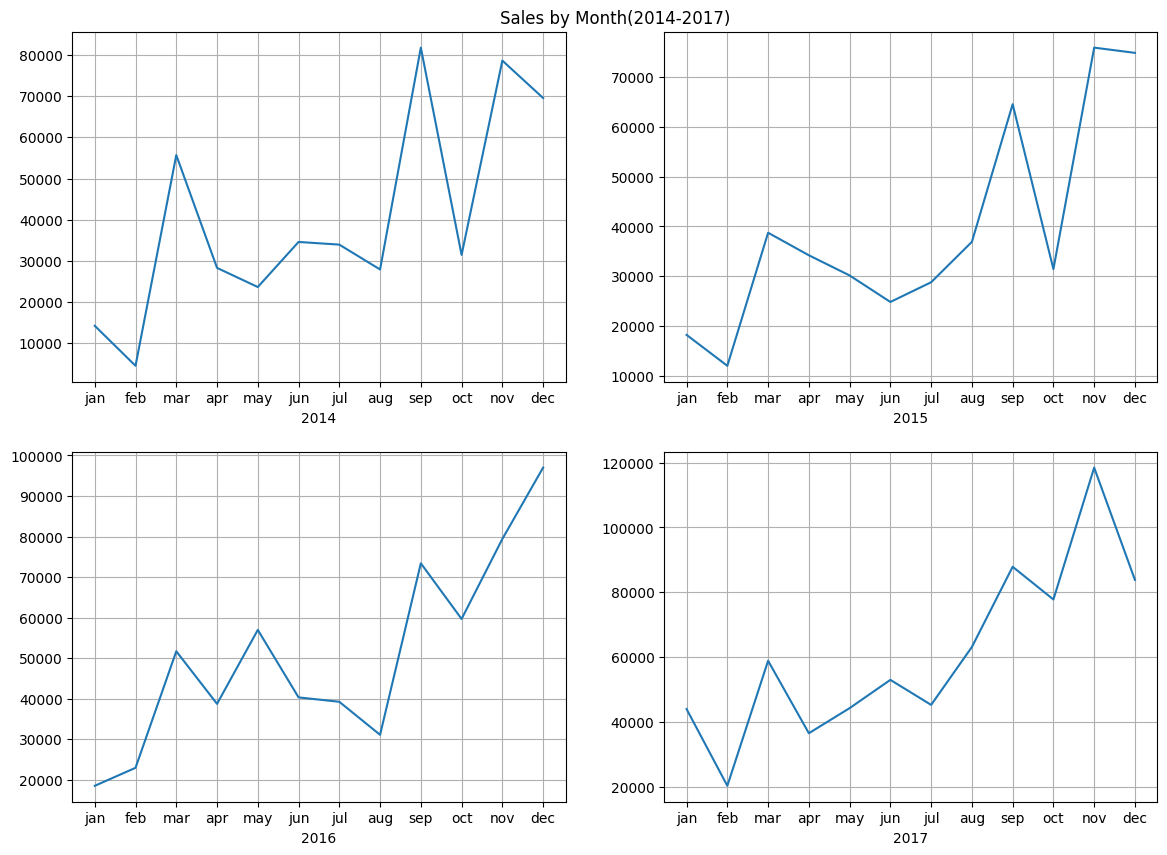

In [77]:
mon_sale_2017 = year_2017.groupby('month')['Sales'].sum().reset_index()
mon_sale_2016 = year_2016.groupby('month')['Sales'].sum().reset_index()
mon_sale_2015 = year_2015.groupby('month')['Sales'].sum().reset_index()
mon_sale_2014 = year_2014.groupby('month')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 10))
plt.title('Sales by Month(2014-2017)')
plt.axis('off')

x = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# 2014
plt.subplot(2, 2, 1)
plt.plot(x, mon_sale_2014['Sales'])
plt.grid()
plt.xlabel('2014')

# 2015
plt.subplot(2, 2, 2)
plt.plot(x, mon_sale_2015['Sales'])
plt.grid()
plt.xlabel('2015')

# 2016
plt.subplot(2, 2, 3)
plt.plot(x, mon_sale_2016['Sales'])
plt.grid()
plt.xlabel('2016')

# 2017
plt.subplot(2, 2, 4)
plt.plot(x, mon_sale_2017['Sales'])
plt.grid()
plt.xlabel('2017')


plt.show()

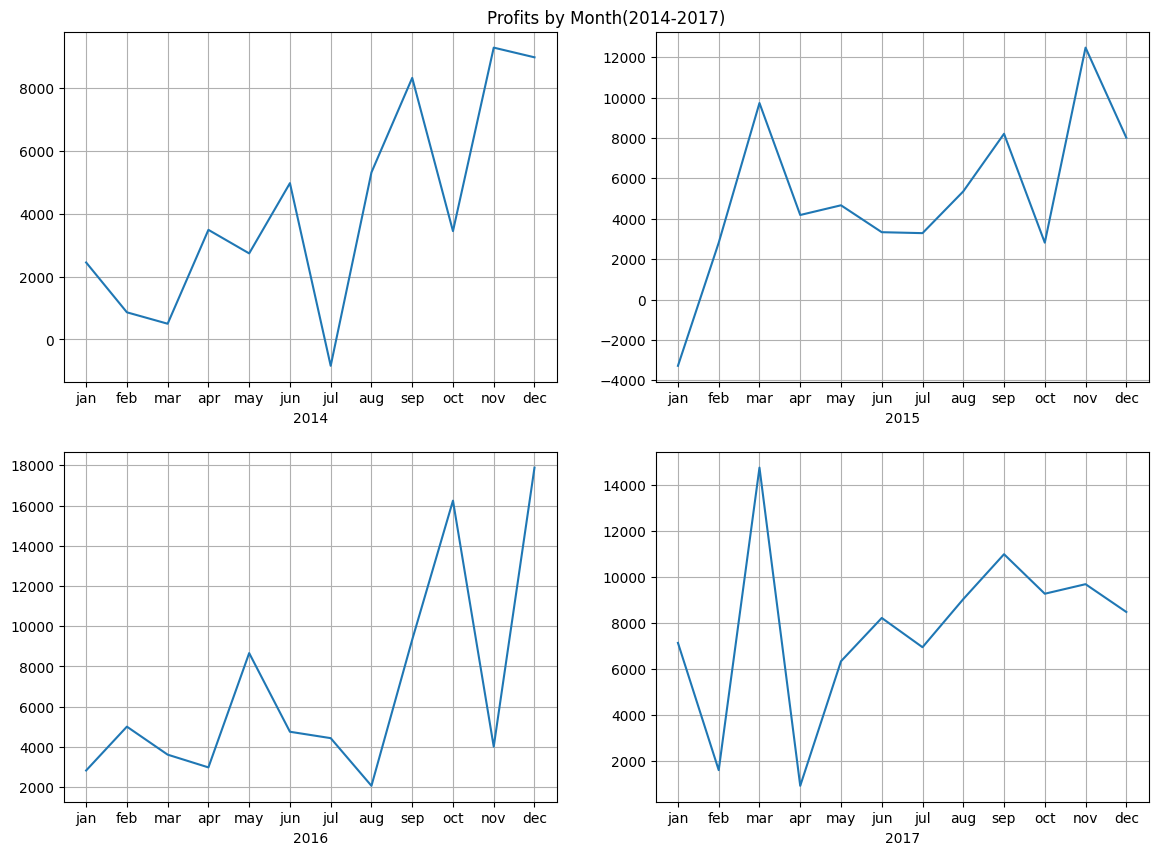

In [78]:
mon_profit_2017 = year_2017.groupby('month')['Profit'].sum().reset_index()
mon_profit_2016 = year_2016.groupby('month')['Profit'].sum().reset_index()
mon_profit_2015 = year_2015.groupby('month')['Profit'].sum().reset_index()
mon_profit_2014 = year_2014.groupby('month')['Profit'].sum().reset_index()


plt.figure(figsize=(14, 10))
plt.title('Profits by Month(2014-2017)')
plt.axis('off')

x = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# 2014
plt.subplot(2, 2, 1)
plt.plot(x, mon_profit_2014['Profit'])
plt.grid()
plt.xlabel('2014')

# 2015
plt.subplot(2, 2, 2)
plt.plot(x, mon_profit_2015['Profit'])
plt.grid()
plt.xlabel('2015')

# 2016
plt.subplot(2, 2, 3)
plt.plot(x, mon_profit_2016['Profit'])
plt.grid()
plt.xlabel('2016')

# 2017
plt.subplot(2, 2, 4)
plt.plot(x, mon_profit_2017['Profit'])
plt.grid()
plt.xlabel('2017')


plt.show()

### Total years wise Sales And Profits

In [79]:
ys = yearly_group['Sales'].sum().reset_index()
yp = yearly_group['Profit'].sum().reset_index()

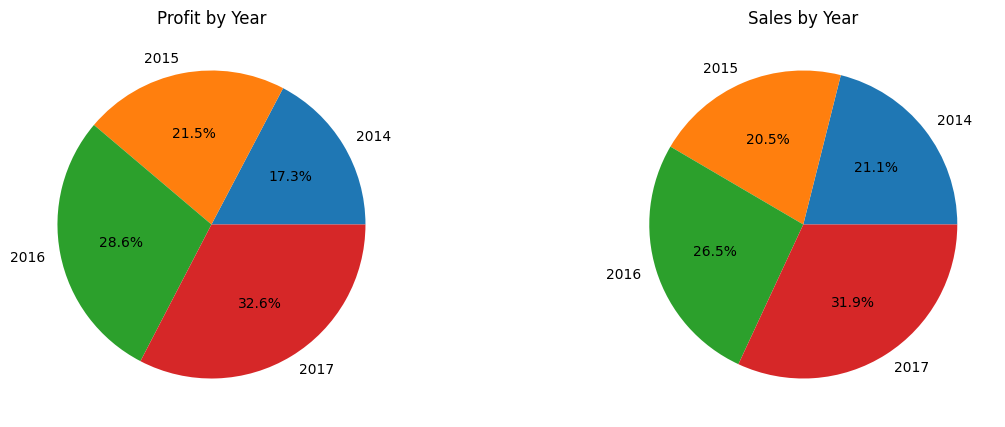

In [80]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.title('Profit by Year')
yp_plot = plt.pie(yp['Profit'], labels=yp['year'], autopct='%1.1f%%')

plt.subplot(1, 2, 2)
plt.title('Sales by Year')
ys_plot = plt.pie(ys['Sales'], labels=ys['year'], autopct='%1.1f%%')

plt.show()

### Encoding Data

In [81]:
data.head(1)

,Row ID,Order ID,month,year,Shipping_Time,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Quantity,Discount,Profit,Sales
0,1,CA-2016-152156,11,2016,3,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,2,0.0,41.9136,261.96


In [82]:
en_cols = ['Order ID', 'year', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']

print("Unique values in categorical columns:")
print()
for col in en_cols:
    print(f"{col} :{data[col].nunique()}")

Unique values in categorical columns:

Order ID :5009
year :4
Ship Mode :4
Customer ID :793
Customer Name :793
Segment :3
City :531
State :49
Region :4
Product ID :1862
Category :3
Sub-Category :17
Product Name :1850


In [83]:
for col in en_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [84]:
data.head(2)

,Row ID,Order ID,month,year,Shipping_Time,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Quantity,Discount,Profit,Sales
0,1,2500,11,2,3,2,143,166,0,194,15,42420,2,12,0,4,386,2,0.0,41.9136,261.96
1,2,2500,11,2,3,2,143,166,0,194,15,42420,2,55,0,5,839,3,0.0,219.5820,731.94


## **CorRelation Chart**

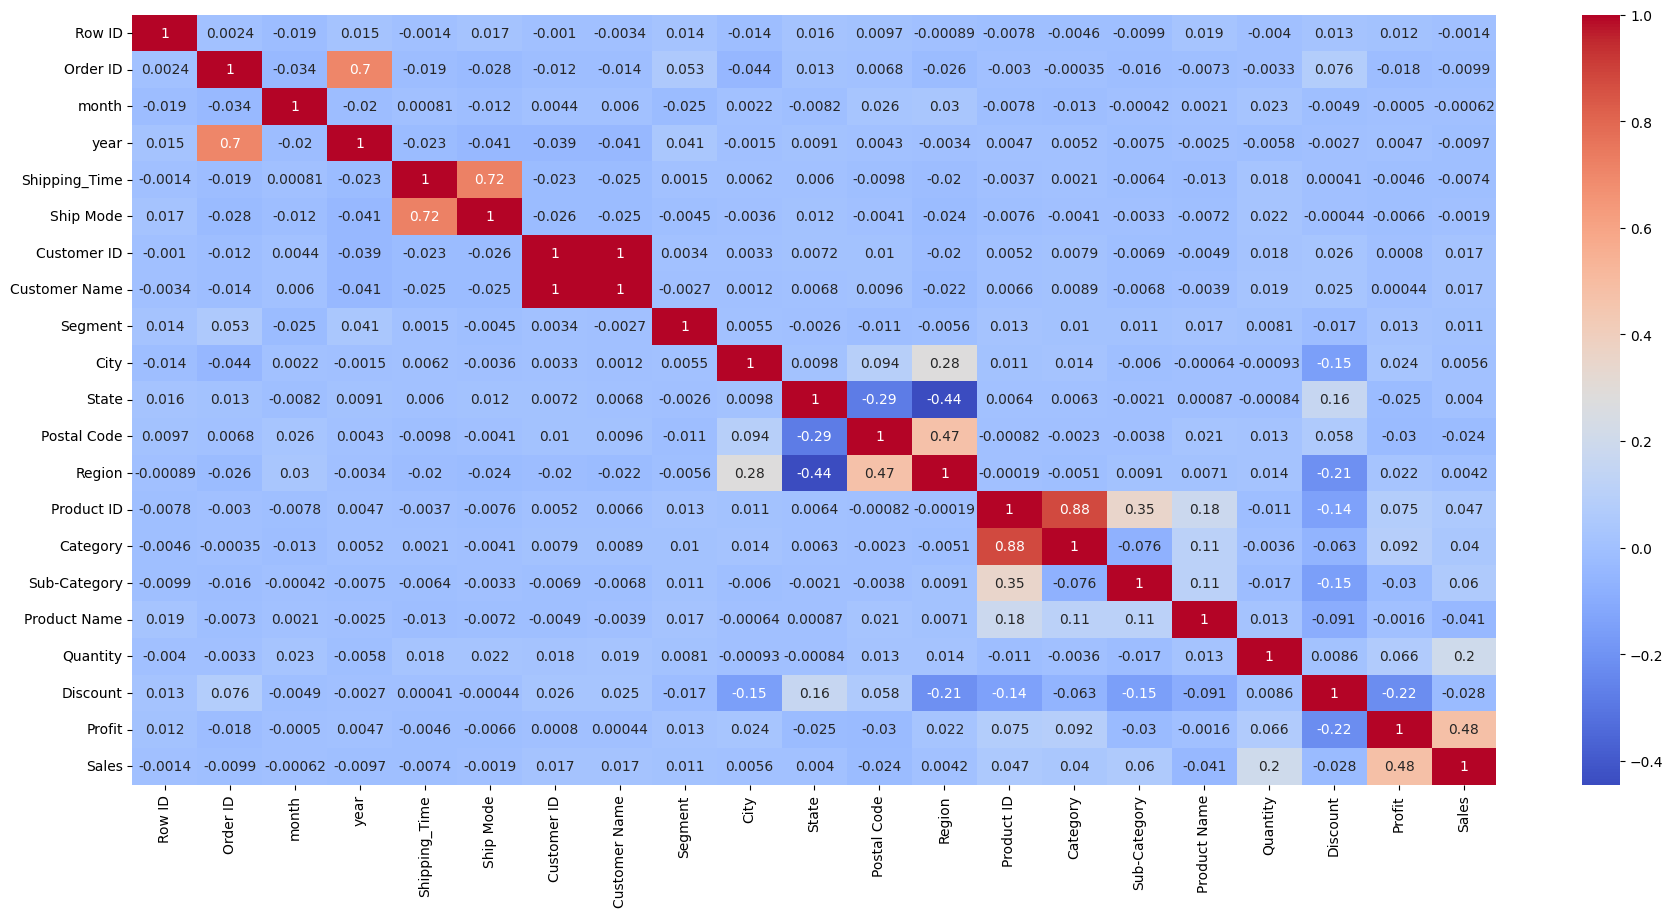

In [85]:
cor = data.corr()

plt.figure(figsize=(22, 10))
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.show()

#### Scaling Data

In [86]:
ss = StandardScaler()
scaler = ss.fit(data)
joblib.dump(scaler, 'scaler.pkl')
print("Data fit and Save Scaler")

Data fit and Save Scaler


In [87]:
data = pd.DataFrame(scaler.transform(data), columns=data.columns)
data.head()

,Row ID,Order ID,month,year,Shipping_Time,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Quantity,Discount,Profit,Sales
0,-1.731878,0.003260,0.971327,0.247234,-0.548318,-0.213513,-1.126376,-1.027688,-0.864161,-0.617727,-0.473638,-0.398302,0.369413,-1.683126,-1.544978,-0.710815,-1.009098,-0.804303,-0.756643,0.056593,0.051510
1,-1.731531,0.003260,0.971327,0.247234,-0.548318,-0.213513,-1.126376,-1.027688,-0.864161,-0.617727,-0.473638,-0.398302,0.369413,-1.601483,-1.544978,-0.512842,-0.156776,-0.354865,-0.756643,0.815054,0.805633
2,-1.731184,-0.136417,-0.550979,0.247234,0.023935,-0.213513,-0.715131,-0.874376,0.447170,-0.100303,-1.247640,1.086817,1.229798,0.090240,0.043552,0.477027,0.960838,-0.804303,-0.756643,-0.093002,-0.345368
3,-1.730838,1.284998,0.666866,-0.642843,1.740693,0.694896,1.332345,1.254465,-0.864161,-0.912371,-0.925139,-0.682407,0.369413,-1.100232,-1.544978,1.664869,-1.046728,0.544012,1.423149,-1.757484,1.167688
4,-1.730491,1.284998,0.666866,-0.642843,1.740693,0.694896,1.332345,1.254465,-0.864161,-0.912371,-0.925139,-0.682407,0.369413,0.792751,0.043552,1.268921,-0.657256,-0.804303,0.212153,-0.111593,-0.332935


#### Train Test Split Data

In [88]:
d_cols = ['month', 'year', 'Shipping_Time', 'Ship Mode',
       'Segment', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Quantity', 'Discount', 'Profit', 'Sales']

data = data[d_cols]

In [89]:
x = data.iloc[:, :-1]
y = data['Sales']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

## **Model Build**

#### Cross Validation

In [90]:
dt_cross = cross_val_score(DecisionTreeRegressor(), x, y, cv=KFold(n_splits=10, shuffle=True, random_state=40))
sorted((dt_cross*100).tolist())

[-71.16640237745277,
 -29.876251664665677,
 2.9801594682871246,
 43.73721460132521,
 51.728765010091294,
 63.11419636525921,
 70.27344814360058,
 80.17113993667476,
 84.98004935547854,
 85.23430462906468]

In [91]:
lr_cross = cross_val_score(LinearRegression(), x, y, cv=KFold(n_splits=10, shuffle=True, random_state=40))
sorted((lr_cross*100).tolist())

[-14.647530627766558,
 -7.3925986447599845,
 -4.866222797116748,
 23.273593497024457,
 23.65671512098969,
 25.4589324502568,
 31.999571691257366,
 36.15280049137996,
 56.278364451615495,
 60.79190366872458]

In [92]:
xgb_cross = cross_val_score(XGBRegressor(), x, y, cv=KFold(n_splits=10, shuffle=True, random_state=40))
sorted((xgb_cross*100).tolist())

[37.72366078440397,
 57.16081528832364,
 60.34679349524363,
 62.43426559479164,
 65.39910430549733,
 73.1883564493693,
 74.42755644761742,
 76.54123438391616,
 79.16498724648358,
 85.89950765986163]

In [93]:
svr_cross = cross_val_score(SVR(), x, y, cv=KFold(n_splits=10, shuffle=True, random_state=40), verbose=0)
sorted((svr_cross*100).tolist())

[27.350931136636337,
 28.64672821596208,
 28.937445730708113,
 51.16714063525405,
 57.57049120848309,
 58.149283406864015,
 60.577285889820175,
 61.100776259220446,
 68.9281247958034,
 70.20760042821246]

In [94]:
svr_cross = cross_val_score(LGBMRegressor(), x, y, cv=KFold(n_splits=10, shuffle=True, random_state=40), verbose=0)
sorted((svr_cross*100).tolist())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1143
[LightGBM] [Info] Number of data points in the train set: 8994, number of used features: 15
[LightGBM] [Info] Start training from score 0.002873
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1140
[LightGBM] [Info] Number of data points in the train set: 8994, number of used features: 15
[LightGBM] [Info] Start training from score -0.003905
[LightGBM] [Warning] Found wh

[40.758189083505634,
 63.38285201300741,
 63.989877359697964,
 76.01276276062988,
 76.54579630192015,
 77.15145099515513,
 78.6292745531218,
 79.01875322013939,
 79.98032943003757,
 82.53695154762748]

In [95]:
rf_cross = cross_val_score(RandomForestRegressor(n_estimators=50), x, y, cv=KFold(n_splits=8, shuffle=True, random_state=42), verbose=0)
sorted((rf_cross*100).tolist())

[54.2571744088304,
 74.70985058757415,
 77.4004685632748,
 78.76525893416553,
 80.03129601262593,
 83.20295479931373,
 89.5806498242443,
 89.7001825288503]

In [96]:
rf_cross = cross_val_score(KNeighborsRegressor(), x, y, cv=KFold(n_splits=8, shuffle=True, random_state=42), verbose=0)
sorted((rf_cross*100).tolist())

[33.18899841047377,
 48.39713661065598,
 49.9875286287395,
 50.88725915777741,
 64.45255496145931,
 66.7590653700822,
 71.47464776807537,
 79.36325049154267]

#### #Linear Regression

In [97]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [98]:
print(f"Train Score: {lr.score(x_train, y_train)*100}\nTest Score: {lr.score(x_test, y_test)*100}")

Train Score: 20.63826163064606
Test Score: 51.93706405722145


In [99]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

RandomForestRegressor()

In [100]:
print(f"Train Score: {rf.score(x_train, y_train)*100}\nTest Score: {rf.score(x_test, y_test)*100}") 

Train Score: 95.42521875925887
Test Score: 89.54339731454436


### **HyperParameter Tuning**

### RandomSearchCV

In [101]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_grid, 
    n_iter=10, 
    cv=3, 
    verbose=2, 
    random_state=40, 
    n_jobs=-1
)
rf_random.fit(x_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=40, verbose=2)

In [102]:
rf_random.best_params_

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 30}

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# **Final Model (RandomForestRegressor)**

In [121]:
rf = RandomForestRegressor(n_estimators=300)
rf.fit(x_train, y_train)

print(f"Train Score: {rf.score(x_train, y_train)*100}\nTest Score: {rf.score(x_test, y_test)*100}") 

Train Score: 95.37178648864297
Test Score: 90.22629731545285


### Evaluation

In [123]:
# MSE metrics 
y_pred = rf.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse*100}")

MSE: 9.887615327938937


In [124]:
r2s = r2_score(y_test, y_pred)
print(f"R2 Score: {r2s*100}")

R2 Score: 90.22629731545285


In [126]:
## Model Save
joblib.dump(rf, 'model.pkl')

['model.pkl']

# **Actual vs Predicted Sales Graph**

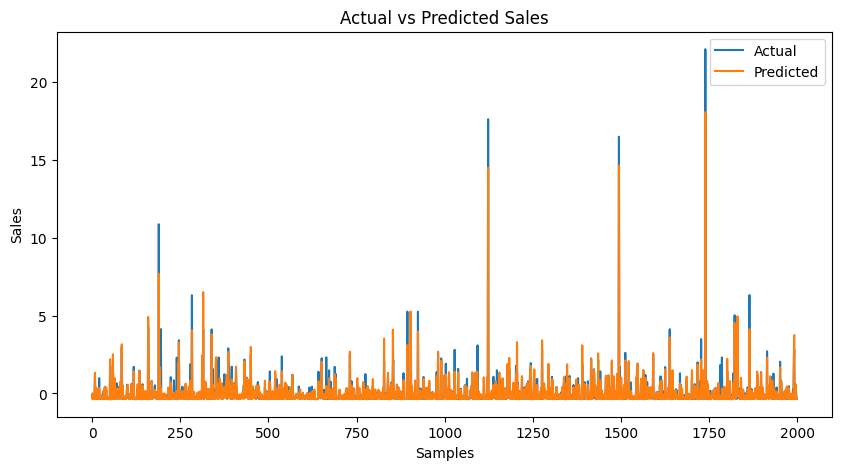

In [125]:
plt.figure(figsize=(10,5))

# Actual
plt.plot(range(len(y_test)), y_test.values, label='Actual')

# Predicted
plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.xlabel('Samples')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales')

plt.legend()
plt.show()

In [129]:
# Prediction Save

submission = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
submission.to_csv('predictions.csv', index=False)
print("Predictions saved to predictions.csv")

Predictions saved to predictions.csv
